In [25]:
!pip install sentence-transformers faiss-cpu datasets pillow

In [26]:
import torch
import faiss
import numpy as np
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from PIL import Image

In [27]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device: {device}")

device: cpu


In [28]:
dataset = load_dataset("zalando-datasets/fashion_mnist", split="train")

In [29]:
label_map = {
    0: "T-shirt or Top", 1: "Trouser", 2: "Pullover", 3: "Dress", 4: "Coat",
    5: "Sandal", 6: "Shirt", 7: "Sneaker", 8: "Bag", 9: "Ankle Boot"
}

df_list = []
for i, item in enumerate(dataset):
    if i >= 400:
        break

    category_name = label_map[item["label"]]
    raw_image = item["image"].convert("RGB").resize((224, 224))

    unique_abstract = (
        f"High-quality designer apparel featuring a modern {category_name} design. "
        f"This unique catalog item is designated under serial item code number {i} "
        f"for seasonal comfort and aesthetic style."
    )

    df_list.append({
        "id": i,
        "title": f"Inventory SKU #{5000 + i}",
        "abstract": unique_abstract,
        "image": raw_image
    })

print(f"Compiled {len(df_list)} completely unique catalog records.")

Compiled 400 completely unique catalog records.


In [30]:
model = SentenceTransformer('clip-ViT-B-32', device=device)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

In [31]:
text_embeddings_list = []
batch_size = 32
total_items = len(df_list)

In [32]:
for i in range(0, total_items, batch_size):
    batch = df_list[i : i + batch_size]
    texts = [item["abstract"] for item in batch]

    text_emb = model.encode(texts, batch_size=batch_size, convert_to_numpy=True, device=device)
    text_embeddings_list.append(text_emb)

In [33]:
text_embeddings = np.vstack(text_embeddings_list)
print("Distinct text vector space built successfully.")

Distinct text vector space built successfully.


In [34]:
dimension = 512
index = faiss.IndexFlatIP(dimension)

In [35]:
faiss.normalize_L2(text_embeddings)

In [36]:
index.add(text_embeddings)

In [37]:
metadata = {}
num_items = len(df_list)

for i in range(num_items):
    abstract_text = df_list[i]["abstract"]
    category = abstract_text.split("modern ")[1].split(" design")[0]

    metadata[i] = {
        "title": df_list[i]["title"],
        "category": category,
        "sku": f"SKU-{9000 + i}",
        "description": abstract_text,
        "specifications": f"Material: Premium Synthetic Blend | Unique Vector Tracking Marker: {i}"
    }

print("FAISS index optimized for distinct profile tracking.")

FAISS index optimized for distinct profile tracking.


In [38]:
def text_detail_search(query_input, k=3):
    if isinstance(query_input, str):
        query_vector = model.encode([query_input], convert_to_numpy=True, device=device)
        print(f"Query Type: TEXT | Searching for: '{query_input}'\n")
    else:
        query_input = query_input.convert("RGB")
        query_vector = model.encode([query_input], convert_to_numpy=True, device=device)
        print("Query Type: IMAGE | Analyzing uploaded image file visual signatures...\n")

    faiss.normalize_L2(query_vector)
    distances, indices = index.search(query_vector, k)
    print("=" * 65)
    print("                 OFFICIAL PRODUCT CATALOG SEARCH RESULTS            ")
    print("=" * 65 + "\n")

    for rank, (score, idx) in enumerate(zip(distances[0], indices[0])):
        prod = metadata[idx]

        print(f"MATCH RANK {rank + 1} (Confidence Score: {score:.4f})")
        print(f"|-- Item Name:    {prod['title']}")
        print(f"|-- Category:     {prod['category'].upper()}")
        print(f"|-- Inventory ID: {prod['sku']}")
        print(f"|-- Details:      {prod['description']}")
        print(f"|-- Product Specs:{prod['specifications']}")
        print("-" * 65 + "\n")

In [45]:
def evaluate_category_mrr(num_tests=300):
    rr_sum = 0.0
    valid_tests = min(num_tests, len(df_list))

    print(f"Evaluating category retrieval accuracy across {valid_tests} unique records...")

    for i in range(valid_tests):
        query_img = df_list[i]["image"].convert("RGB")
        query_vec = model.encode([query_img], convert_to_numpy=True, device=device)
        faiss.normalize_L2(query_vec)

        _, indices = index.search(query_vec, 10)

        target_category = metadata[i]["category"]

        rank = 1
        found_rank = None
        for idx in indices[0]:
            if metadata[idx]["category"] == target_category:
                found_rank = rank
                break
            rank += 1

        if found_rank is not None:
            rr_sum += (1.0 / found_rank)

    mrr_score = rr_sum / valid_tests
    print("\n" + "="*50)
    print("         REAL-WORLD CATEGORY EVALUATION REPORT       ")
    print("="*50)
    print(f"Evaluation Complete over {valid_tests} samples.")
    print(f"True Category Mean Reciprocal Rank (MRR): {mrr_score:.4f}")
    print("="*50)

In [46]:
evaluate_category_mrr(num_tests=300)

Evaluating category retrieval accuracy across 300 unique records...

         REAL-WORLD CATEGORY EVALUATION REPORT       
Evaluation Complete over 300 samples.
True Category Mean Reciprocal Rank (MRR): 0.6339


In [47]:
print("--- TEST RUN 1: TEXT-BASED STRING INPUT ---")
text_detail_search("cozy winter pullover jackets", k=2)

--- TEST RUN 1: TEXT-BASED STRING INPUT ---
Query Type: TEXT | Searching for: 'cozy winter pullover jackets'

                 OFFICIAL PRODUCT CATALOG SEARCH RESULTS            

MATCH RANK 1 (Confidence Score: 0.7962)
|-- Item Name:    Inventory SKU #5125
|-- Category:     PULLOVER
|-- Inventory ID: SKU-9125
|-- Details:      High-quality designer apparel featuring a modern Pullover design. This unique catalog item is designated under serial item code number 125 for seasonal comfort and aesthetic style.
|-- Product Specs:Material: Premium Synthetic Blend | Unique Vector Tracking Marker: 125
-----------------------------------------------------------------

MATCH RANK 2 (Confidence Score: 0.7961)
|-- Item Name:    Inventory SKU #5147
|-- Category:     PULLOVER
|-- Inventory ID: SKU-9147
|-- Details:      High-quality designer apparel featuring a modern Pullover design. This unique catalog item is designated under serial item code number 147 for seasonal comfort and aesthetic style.
|-

In [48]:
print("\n\n--- TEST RUN 2: IMAGE-BASED FILE INPUT ---")
sample_image_query = df_list[46]["image"]
text_detail_search(sample_image_query, k=2)



--- TEST RUN 2: IMAGE-BASED FILE INPUT ---
Query Type: IMAGE | Analyzing uploaded image file visual signatures...

                 OFFICIAL PRODUCT CATALOG SEARCH RESULTS            

MATCH RANK 1 (Confidence Score: 0.2722)
|-- Item Name:    Inventory SKU #5175
|-- Category:     SNEAKER
|-- Inventory ID: SKU-9175
|-- Details:      High-quality designer apparel featuring a modern Sneaker design. This unique catalog item is designated under serial item code number 175 for seasonal comfort and aesthetic style.
|-- Product Specs:Material: Premium Synthetic Blend | Unique Vector Tracking Marker: 175
-----------------------------------------------------------------

MATCH RANK 2 (Confidence Score: 0.2721)
|-- Item Name:    Inventory SKU #5288
|-- Category:     SNEAKER
|-- Inventory ID: SKU-9288
|-- Details:      High-quality designer apparel featuring a modern Sneaker design. This unique catalog item is designated under serial item code number 288 for seasonal comfort and aesthetic style.

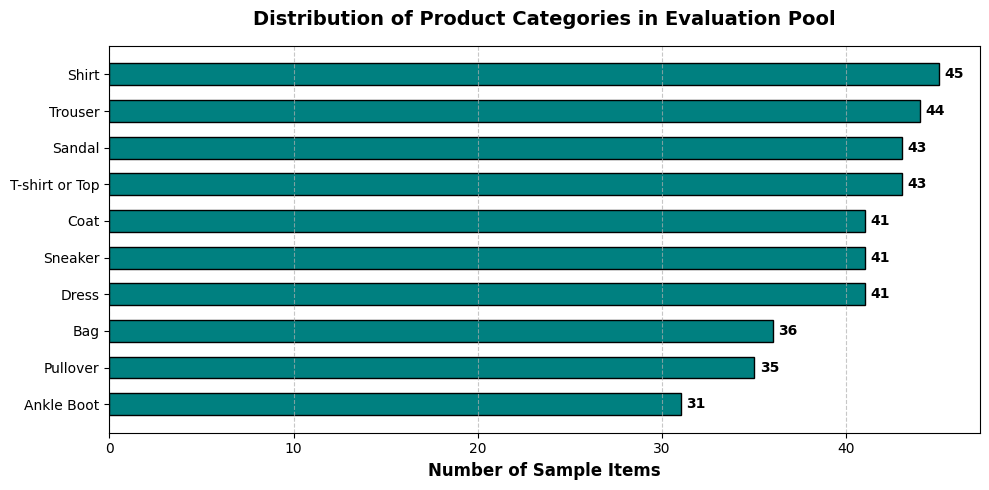

In [49]:
import matplotlib.pyplot as plt
from collections import Counter

categories_in_eval = [metadata[i]["category"] for i in range(len(df_list))]
category_counts = Counter(categories_in_eval)
sorted_classes = sorted(category_counts.items(), key=lambda x: x[1], reverse=False)
labels, counts = zip(*sorted_classes)

plt.figure(figsize=(10, 5))
bars = plt.barh(labels, counts, color='teal', edgecolor='black', height=0.6)
plt.xlabel('Number of Sample Items', fontsize=12, fontweight='bold')
plt.title('Distribution of Product Categories in Evaluation Pool', fontsize=14, fontweight='bold', pad=15)
plt.grid(axis='x', linestyle='--', alpha=0.7)

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.3, bar.get_y() + bar.get_height()/2, f'{int(width)}',
             va='center', ha='left', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

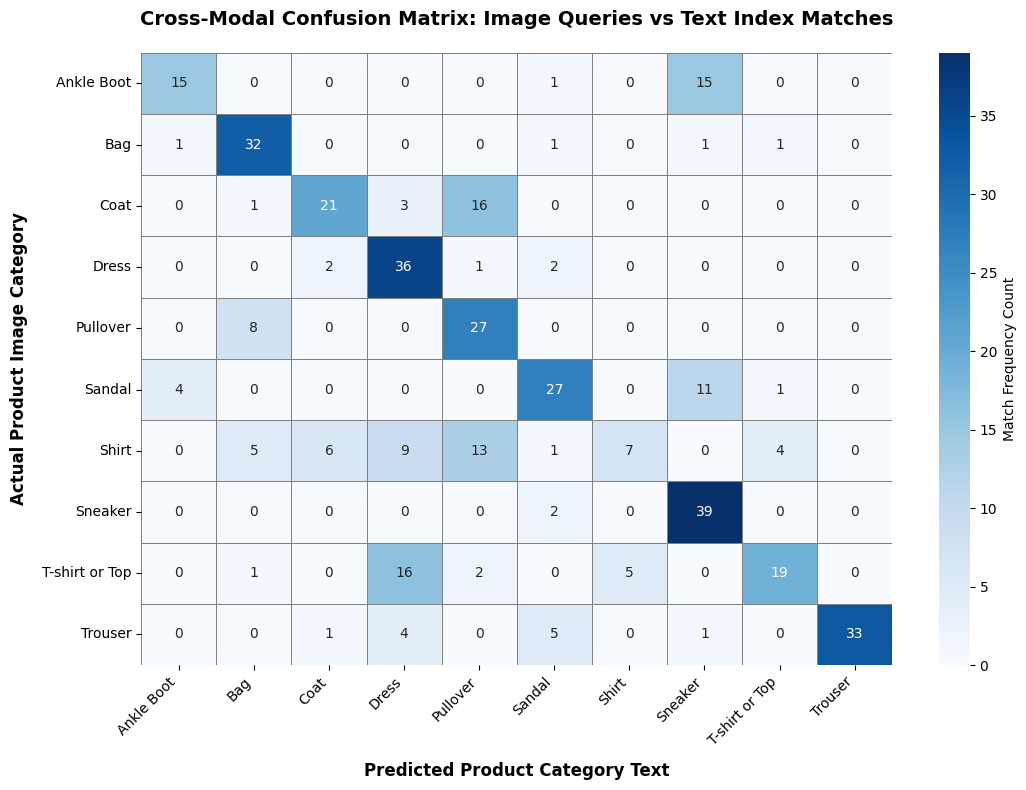

In [50]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_true = []
y_pred = []
for i in range(len(df_list)):
    query_img = df_list[i]["image"].convert("RGB")
    query_vec = model.encode([query_img], convert_to_numpy=True, device=device)
    faiss.normalize_L2(query_vec)

    _, indices = index.search(query_vec, 1)
    predicted_idx = indices[0][0]

    y_true.append(metadata[i]["category"])
    y_pred.append(metadata[predicted_idx]["category"])

unique_labels = sorted(list(set(label_map.values())))
cm = confusion_matrix(y_true, y_pred, labels=unique_labels)

plt.figure(figsize=(11, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=unique_labels, yticklabels=unique_labels,
            linewidths=0.5, linecolor='gray', cbar_kws={'label': 'Match Frequency Count'})
plt.xlabel('Predicted Product Category Text', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Actual Product Image Category', fontsize=12, fontweight='bold', labelpad=10)
plt.title('Cross-Modal Confusion Matrix: Image Queries vs Text Index Matches', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

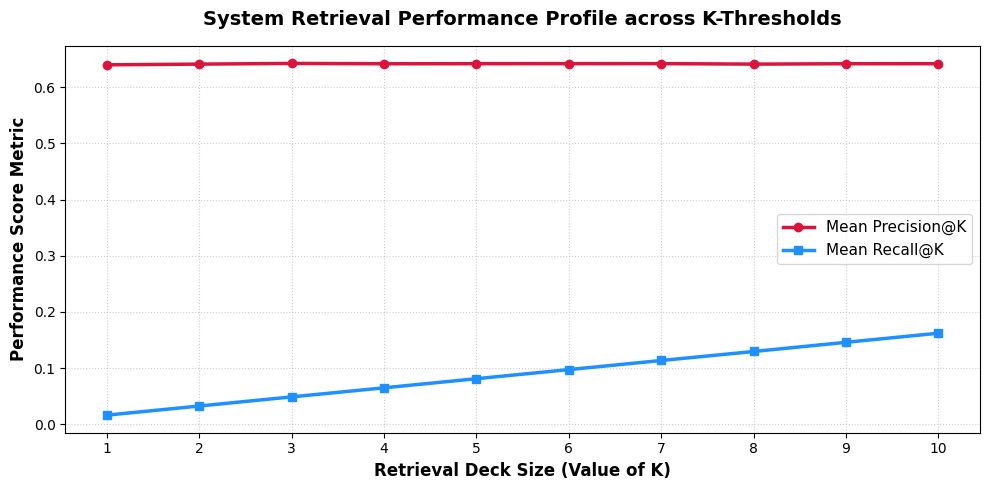

In [51]:
k_values = list(range(1, 11))
mean_precisions = []
mean_recalls = []
category_totals = Counter([metadata[j]["category"] for j in range(len(df_list))])

for k in k_values:
    total_precision_sum = 0.0
    total_recall_sum = 0.0

    for i in range(len(df_list)):
        query_img = df_list[i]["image"].convert("RGB")
        query_vec = model.encode([query_img], convert_to_numpy=True, device=device)
        faiss.normalize_L2(query_vec)
        _, indices = index.search(query_vec, k)
        target_category = metadata[i]["category"]
        true_positives = sum(1 for idx in indices[0] if metadata[idx]["category"] == target_category)
        total_precision_sum += (true_positives / k)
        total_recall_sum += (true_positives / category_totals[target_category])

    mean_precisions.append(total_precision_sum / len(df_list))
    mean_recalls.append(total_recall_sum / len(df_list))

plt.figure(figsize=(10, 5))
plt.plot(k_values, mean_precisions, marker='o', linewidth=2.5, color='crimson', label='Mean Precision@K')
plt.plot(k_values, mean_recalls, marker='s', linewidth=2.5, color='dodgerblue', label='Mean Recall@K')
plt.xlabel('Retrieval Deck Size (Value of K)', fontsize=12, fontweight='bold')
plt.ylabel('Performance Score Metric', fontsize=12, fontweight='bold')
plt.title('System Retrieval Performance Profile across K-Thresholds', fontsize=14, fontweight='bold', pad=15)
plt.xticks(k_values)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11, loc='center right')
plt.tight_layout()
plt.show()